In [27]:
import os
import glob
import graphical_sampling as gs
import pandas as pd
import numpy as np
import itertools
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities

In [40]:
N = 100000
n = 1000
rng = gs.random.rng()
coords = rng.random_coordinates((N, 2))
probs = rng.unequal_probabilities(n, N)
modified_probs = inclusion_probabilities(probs, n=n)
pop = gs.Population(coords, modified_probs)

In [42]:
fbn = gs.clustering.FIPBalancedNMeans(n=n, mode='soft', n_init=10, tol=1e-4, max_iter=100)
fbn.fit(pop)

<Axes: title={'center': 'FIP Balanced 1000-Means Soft Clustering'}, xlabel='$X_1$', ylabel='$X_2$'>

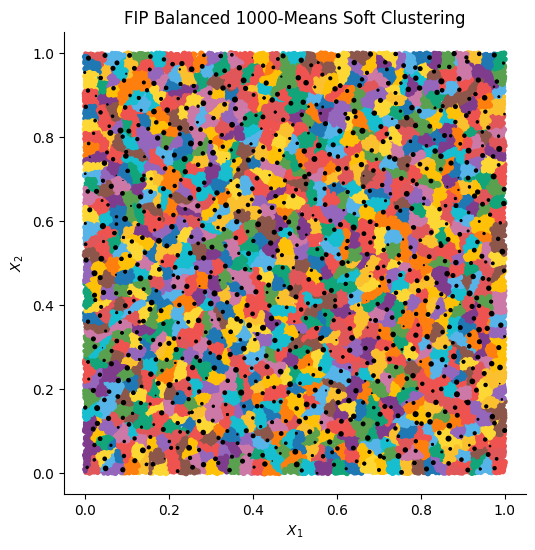

In [43]:
fbn.plot()

In [6]:
from itertools import product

n_inits = [10, 25, 50, 100, 200]
tols = [1e-1, 1e-2, 1e-4, 1e-5, 1e-9]
max_iters = [100, 300, 500]

results = []

for (n_init, tol, max_iter) in product(n_inits, tols, max_iters):
    avg = 0
    for _ in range(10):
        fbn = gs.clustering.FIPBalancedNMeans(n=n, mode='hard', n_init=n_init, tol=tol, max_iter=max_iter)
        fbn.fit(pop)
        sums = [0 for _ in range(n)]
        for i in range(n):
            sums[i] = pop.probs[fbn.labels == i].sum()
        mean_abs_error = np.abs(np.array(sums) - 1).mean()
        avg += mean_abs_error
    avg = avg/10
    print((n_init, tol, max_iter), round(avg, 4))
    results.append((avg, (n_init, tol, max_iter)))

(10, 0.1, 100) 0.1536
(10, 0.1, 300) 0.139
(10, 0.1, 500) 0.1553
(10, 0.01, 100) 0.125
(10, 0.01, 300) 0.1286
(10, 0.01, 500) 0.1161
(10, 0.0001, 100) 0.0945
(10, 0.0001, 300) 0.1104
(10, 0.0001, 500) 0.1131
(10, 1e-05, 100) 0.1078
(10, 1e-05, 300) 0.1142
(10, 1e-05, 500) 0.1131
(10, 1e-09, 100) 0.1128
(10, 1e-09, 300) 0.1053
(10, 1e-09, 500) 0.0986
(25, 0.1, 100) 0.1423
(25, 0.1, 300) 0.1452
(25, 0.1, 500) 0.1497
(25, 0.01, 100) 0.1266
(25, 0.01, 300) 0.1121
(25, 0.01, 500) 0.1206
(25, 0.0001, 100) 0.1065
(25, 0.0001, 300) 0.0973
(25, 0.0001, 500) 0.0984
(25, 1e-05, 100) 0.0964
(25, 1e-05, 300) 0.1017
(25, 1e-05, 500) 0.0973
(25, 1e-09, 100) 0.0979
(25, 1e-09, 300) 0.1011
(25, 1e-09, 500) 0.1003
(50, 0.1, 100) 0.1485
(50, 0.1, 300) 0.1414
(50, 0.1, 500) 0.1403
(50, 0.01, 100) 0.125
(50, 0.01, 300) 0.1102
(50, 0.01, 500) 0.114
(50, 0.0001, 100) 0.0942
(50, 0.0001, 300) 0.0933
(50, 0.0001, 500) 0.0977
(50, 1e-05, 100) 0.093
(50, 1e-05, 300) 0.096
(50, 1e-05, 500) 0.0995
(50, 1e-09, 100)

In [8]:
sorted(results, key=lambda x: x[0])[:10]

[(np.float64(0.09096587686691919), (50, 1e-09, 100)),
 (np.float64(0.09182014349901232), (100, 0.0001, 500)),
 (np.float64(0.0918650921997901), (200, 1e-09, 500)),
 (np.float64(0.0920943371912615), (200, 1e-05, 500)),
 (np.float64(0.0924239950192984), (200, 1e-09, 100)),
 (np.float64(0.09242581037031312), (200, 1e-05, 100)),
 (np.float64(0.09245648029826563), (200, 1e-05, 300)),
 (np.float64(0.09300475848461362), (50, 1e-05, 100)),
 (np.float64(0.09305117137967969), (100, 1e-09, 300)),
 (np.float64(0.09305382781065048), (100, 1e-09, 500))]

In [12]:
from itertools import product

n_inits = [50]
tols = [1e-9]
max_iters = [100]

results2 = []

for (n_init, tol, max_iter) in product(n_inits, tols, max_iters):
    avg = 0
    for _ in range(100):
        fbn = gs.clustering.FIPBalancedNMeans(n=n, mode='hard', n_init=n_init, tol=tol, max_iter=max_iter)
        fbn.fit(pop)
        sums = [0 for _ in range(n)]
        for i in range(n):
            sums[i] = pop.probs[fbn.labels == i].sum()
        mean_abs_error = np.abs(np.array(sums) - 1).mean()
        avg += mean_abs_error
    avg = avg/100
    print((n_init, tol, max_iter), round(avg, 4))
    results2.append((avg, (n_init, tol, max_iter)))

(50, 1e-09, 100) 0.0948


In [14]:
sums = [0 for _ in range(n)]
for i in range(n):
    sums[i] = pop.probs[fbn.labels == i].sum()

mean_abs_error = np.abs(np.array(sums) - 1).mean()

for i in range(n):
    print(f"Cluster {i}: Sum of probabilities = {sums[i]:.4f}")

print(f"Mean Abs Error: {np.abs(np.array(sums) - 1).mean():.4f}")

Cluster 0: Sum of probabilities = 0.9979
Cluster 1: Sum of probabilities = 1.2363
Cluster 2: Sum of probabilities = 1.0553
Cluster 3: Sum of probabilities = 0.9866
Cluster 4: Sum of probabilities = 1.0729
Cluster 5: Sum of probabilities = 0.8789
Cluster 6: Sum of probabilities = 0.9473
Cluster 7: Sum of probabilities = 1.2048
Cluster 8: Sum of probabilities = 0.7620
Cluster 9: Sum of probabilities = 0.8581
Mean Abs Error: 0.1138


In [5]:
for i in range(n):
    print(f"Cluster {i+1}:")
    print(f"sum={(fbn.membership[:, i] * pop.probs).sum():.4f}")

Cluster 1:


TypeError: 'NoneType' object is not subscriptable

<Axes: title={'center': 'FIP Balanced 10-Means Hard Clustering'}, xlabel='$X_1$', ylabel='$X_2$'>

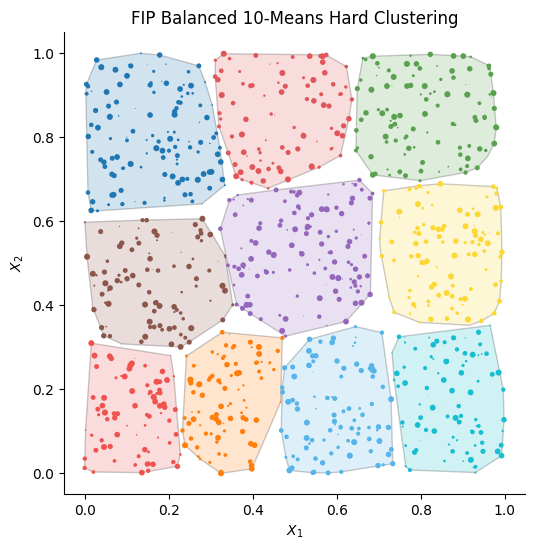

In [15]:
fbn.plot(dpi=100)

<Axes: title={'center': 'FIP Balanced 10-Means Soft Clustering'}, xlabel='$X_1$', ylabel='$X_2$'>

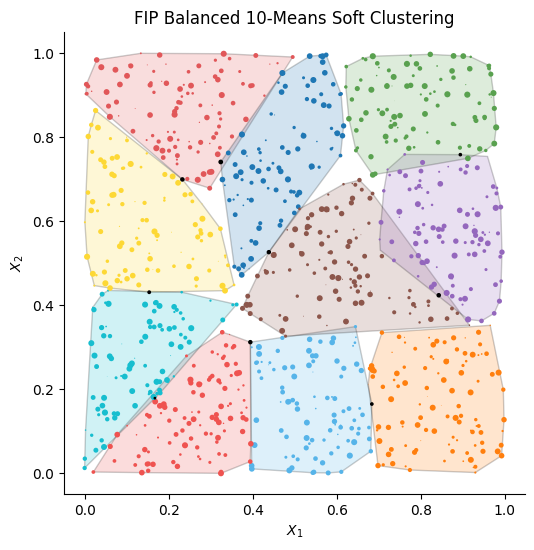

In [17]:
fbn.plot(dpi=100)